In [1]:
# imports

import pickle
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
# load data

with open ('WESAD/S2/S2.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

wrist = data['signal']['wrist']
print(data.keys())
print(wrist.keys())

dict_keys(['signal', 'label', 'subject'])
dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])


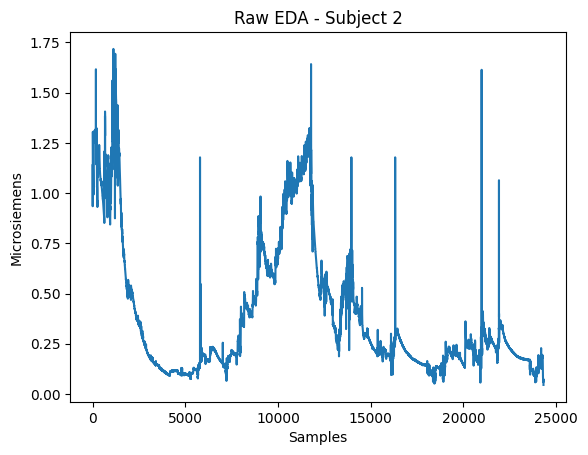

In [3]:
# process the raw EDA + plot

EDA_RATE = 4
LABEL_RATE = 700

eda_raw = wrist['EDA'].flatten()
eda_signals, eda_info = nk.eda_process(eda_raw, sampling_rate=EDA_RATE)
labels = data['label'].flatten()
plt.plot(eda_raw)
plt.title('Raw EDA - Subject 2')
plt.xlabel('Samples')
plt.ylabel('Microsiemens')
plt.show()

In [4]:
# downsample -- basically GCF
label_downsample_factor = LABEL_RATE // EDA_RATE

# takes every 175th label in order to make it the same size as the EDA data
labels_eda = labels[::label_downsample_factor]

# trim the label array so the two arrays are aligned
eda_length = len(wrist['EDA'].flatten())
labels_eda = labels_eda[:eda_length]

print(f"EDA samples: {eda_length}")
print(f"Downsampled labels: {len(labels_eda)}")


eda_signals['Label'] = labels_eda
print("Label column added successfully")
print(eda_signals['Label'].value_counts())

EDA samples: 24316
Downsampled labels: 24316
Label column added successfully
Label
0    12244
1     4576
4     3072
2     2460
3     1448
6      260
7      256
Name: count, dtype: int64


In [5]:
# ensure that dataframe only includes two labels -- 1, which is baseline, and 2, which is stress -- the actual model will probably just be baseline to compare but idk
eda_signals = eda_signals[eda_signals['Label'].isin([1, 2])].copy()

# turns baseline from 1 and 2 to 0 and 1 (since 2 -> True -> 1, and 1 -> False -> 0)
eda_signals['Label'] = (eda_signals['Label'] == 2).astype(int)
print(f"Baseline samples: {(eda_signals['Label'] == 0).sum()}")
print(f"Stress samples: {(eda_signals['Label'] == 1).sum()}")

Baseline samples: 4576
Stress samples: 2460


In [6]:
def extract_features_from_window(window):

    features = {}

    # -- Tonic --
    tonic = window['EDA_Tonic'].values

    # calculates statistics
    features['tonic_mean'] = np.mean(tonic)
    features['tonic_std'] = np.std(tonic)
    features['tonic_min'] = np.min(tonic)
    features['tonic_max'] = np.max(tonic)
    features['tonic_slope'] = np.polyfit(
        np.arange(len(tonic)), tonic, 1)[0]

    # -- Phasic --
    phasic = window['EDA_Phasic'].values

    # calculates statistics
    features['phasic_mean'] = np.mean(phasic)
    features['phasic_std'] = np.std(phasic)
    features['phasic_min'] = np.min(phasic)
    features['phasic_max'] = np.max(phasic)

    # -- SCR peak --
    scr_peaks = window['SCR_Peaks'].values # 1 at peaks, 0 elsewhere
    features['scr_count'] = np.sum(scr_peaks) # gets the total # of peaks
    peak_amplitudes = window.loc[
        window['SCR_Peaks'] == 1, 'SCR_Amplitude'].values # gives an array of amplitudes for all detected peaks (window.loc[condition, column])

    # mean amplitude... it says it right there.
    features['scr_mean_amplitude'] = (
        np.mean(peak_amplitudes) if len(peak_amplitudes) > 0 else 0
    )

    # time it took for the EDA to rise and recover away from / back to baseline
    features['scr_mean_rise_time'] = (
        np.mean(window.loc[
            window['SCR_Peaks'] == 1, 'SCR_RiseTime'
            ].values) if len(peak_amplitudes) > 0 else 0
    )

    features['scr_mean_recovery_time'] = (
        np.mean(window.loc[
            window['SCR_Peaks'] == 1, 'SCR_RecoveryTime'].values) if len(peak_amplitudes) > 0 else 0
    )
    
    return features
    

In [7]:
WINDOW_SIZE = 60
STEP_SIZE = 30
SAMPLES_PER_WINDOW = WINDOW_SIZE * EDA_RATE
SAMPLES_PER_STEP = STEP_SIZE * EDA_RATE

feature_rows = []
label_rows = []

# resets the dataframe index to 0, since values that weren't labeled 1 and 2 were dropped
eda_signals = eda_signals.reset_index(drop=True)

start = 0
windows_skipped = 0

while start + SAMPLES_PER_WINDOW <= len(eda_signals):
    end = start + SAMPLES_PER_WINDOW
    window = eda_signals.iloc[start:end]

    window_labels = window['Label'].values

    # if there is more than one label in the window, it gets skipped because it has both stressed and baseline data and doesn't extract
    if len(np.unique(window_labels)) > 1:
        windows_skipped += 1
        start += SAMPLES_PER_STEP
        continue

    # extracts features from the window... duh
    # and then adds a new row to the feature_rows array
    features = extract_features_from_window(window)
    feature_rows.append(features)
    label_rows.append(window_labels[0])

    start += SAMPLES_PER_STEP

# converts the list of dictionaries (i.e. feature_rows) into a DataFrame with each dictionary being a row and the key being the column 
# feature_df and label_array is the training data
feature_df = pd.DataFrame(feature_rows)
label_array = np.array(label_rows)

print(f"Windows extracted: {len(feature_df)}")
print(f"Windows skipped (boundary): {windows_skipped}")
print(f"Features per window: {len(feature_df.columns)}")
print(f"Baseline windows: {np.sum(label_array == 0)}")
print(f"Stress windows: {np.sum(label_array == 1)}")
print(f"\nFeature names: {list(feature_df.columns)}")

Windows extracted: 55
Windows skipped (boundary): 2
Features per window: 13
Baseline windows: 37
Stress windows: 18

Feature names: ['tonic_mean', 'tonic_std', 'tonic_min', 'tonic_max', 'tonic_slope', 'phasic_mean', 'phasic_std', 'phasic_min', 'phasic_max', 'scr_count', 'scr_mean_amplitude', 'scr_mean_rise_time', 'scr_mean_recovery_time']


In [8]:
# checks for NaN values in each column and fills all of them with 0
print("Missing values per feature:")
print(feature_df.isnull().sum())

feature_df = feature_df.fillna(0)
print("\nAfter filling, missing values are:")
print(feature_df.isnull().sum().sum())

Missing values per feature:
tonic_mean                0
tonic_std                 0
tonic_min                 0
tonic_max                 0
tonic_slope               0
phasic_mean               0
phasic_std                0
phasic_min                0
phasic_max                0
scr_count                 0
scr_mean_amplitude        0
scr_mean_rise_time        0
scr_mean_recovery_time    0
dtype: int64

After filling, missing values are:
0


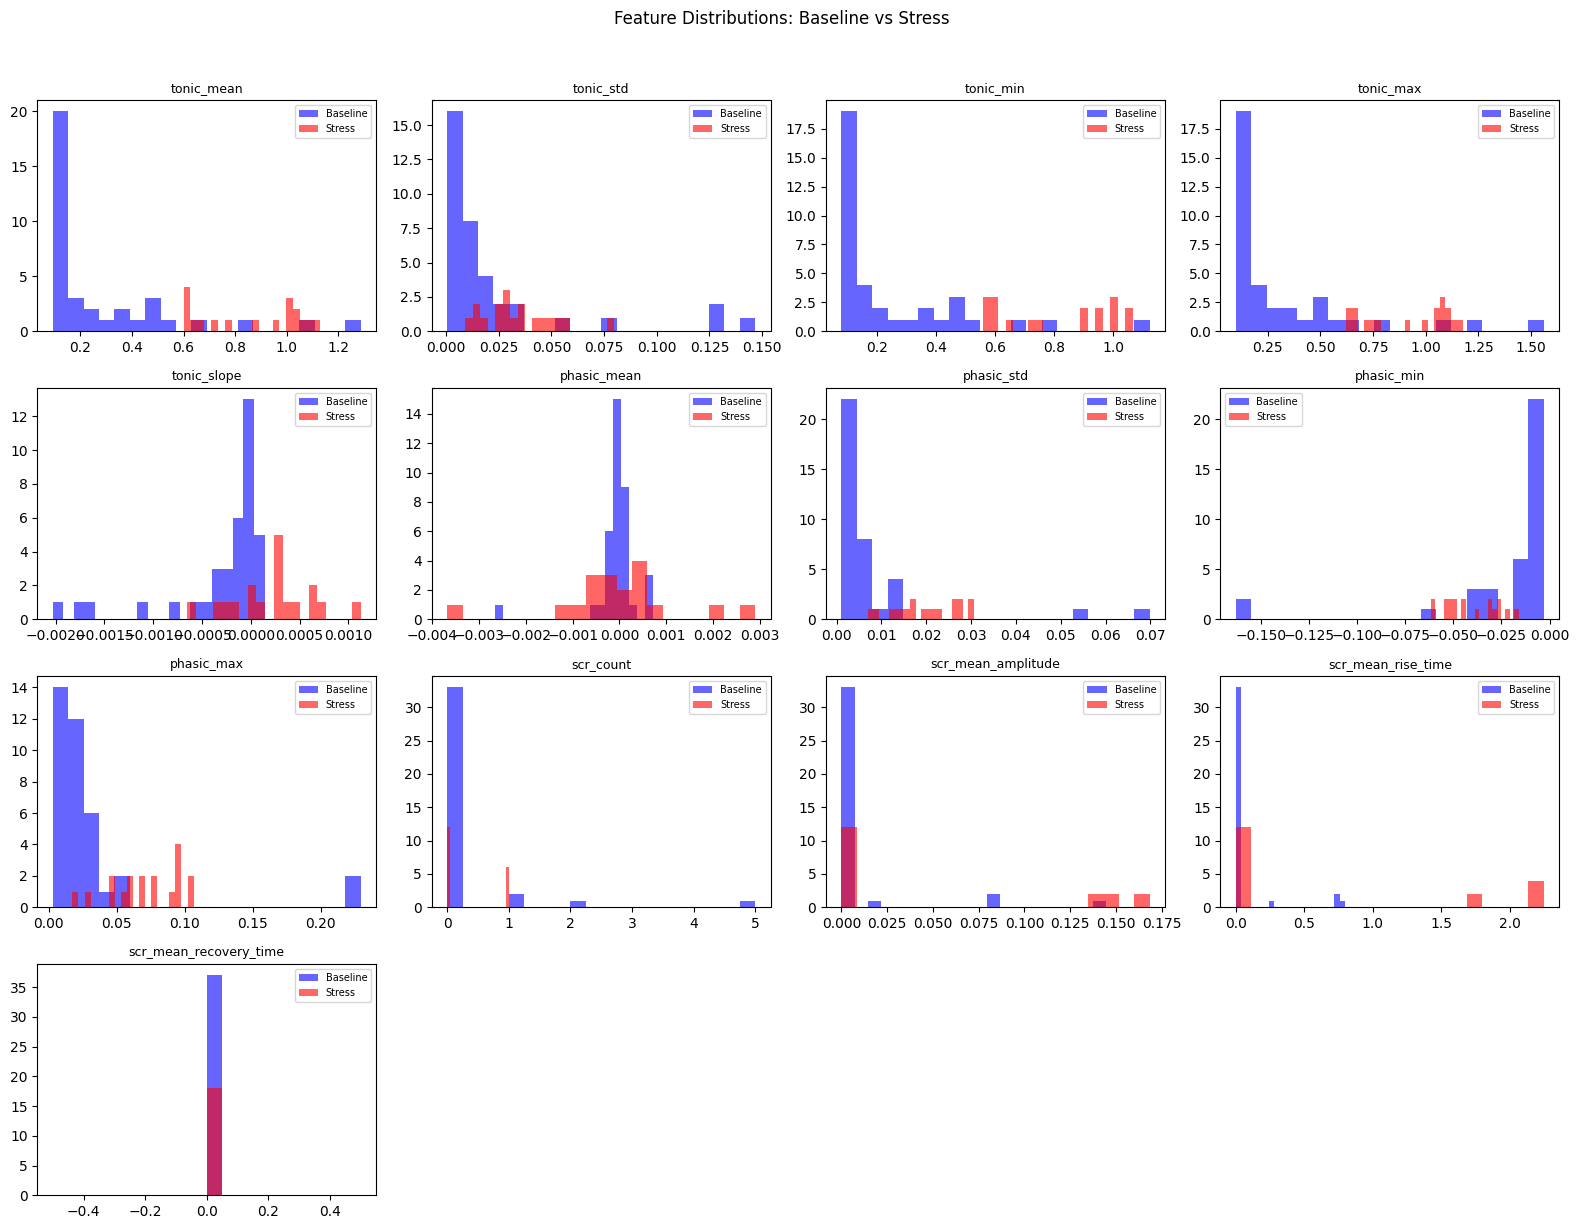

In [9]:
import math

# gets list of column names and counts them
feature_names = list(feature_df.columns)
n_features = len(feature_names)

# calculate grid dimensions
n_cols= 4
n_rows = math.ceil(n_features / n_cols)

# create figure with grid of subplots -- fig is the figure object with axes being a 2D array
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3)) # the width is 16 by 3*number of rows
axes = axes.flatten()

feature_names = list(feature_df.columns)

for i, feature_name in enumerate(feature_names):
    ax = axes[i]

    # selects feature values for each class -- False or 0 = baseline, True or 1 = stress, 
    baseline_vals = feature_df[feature_name][label_array == 0]
    stress_vals = feature_df[feature_name][label_array == 1]

    # draws histograms
    ax.hist(baseline_vals, alpha=0.6, label='Baseline', color='blue', bins=20)
    ax.hist(stress_vals, alpha=0.6, label='Stress', color='red', bins=20)
    ax.set_title(feature_name, fontsize=9)
    ax.legend(fontsize=7)

# hide unused subpolots
for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions: Baseline vs Stress', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# X is the DataFrame as a numpy array, and y is the array of labels since scikit expects numpy arrays
X = feature_df.values
y = label_array

scaler = StandardScaler() # gets the z value -- ap stats throwback so awesome
X_scaled = scaler.fit_transform(X) # applies it to X.fit_transform

# train on the full dataset -- mostly just a sanity check 
# n_estimators -> the number of individual decision trees.
# random_state -> random seed to ensure you get idnetical results. 42 is arbitrary tho.
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_scaled, y)

y_pred = clf.predict(X_scaled)
print(f"In-sample accuracy: {accuracy_score(y, y_pred):.3f}")
# expect to be high -- it's not real accuracy, it just confirms that it works

In-sample accuracy: 1.000


Feature importances:
               feature  importance
            tonic_mean    0.213397
             tonic_min    0.178689
            phasic_std    0.145319
           tonic_slope    0.122627
             tonic_max    0.114898
            phasic_max    0.085242
             tonic_std    0.060173
            phasic_min    0.043951
           phasic_mean    0.012143
             scr_count    0.011530
    scr_mean_amplitude    0.009200
    scr_mean_rise_time    0.002832
scr_mean_recovery_time    0.000000


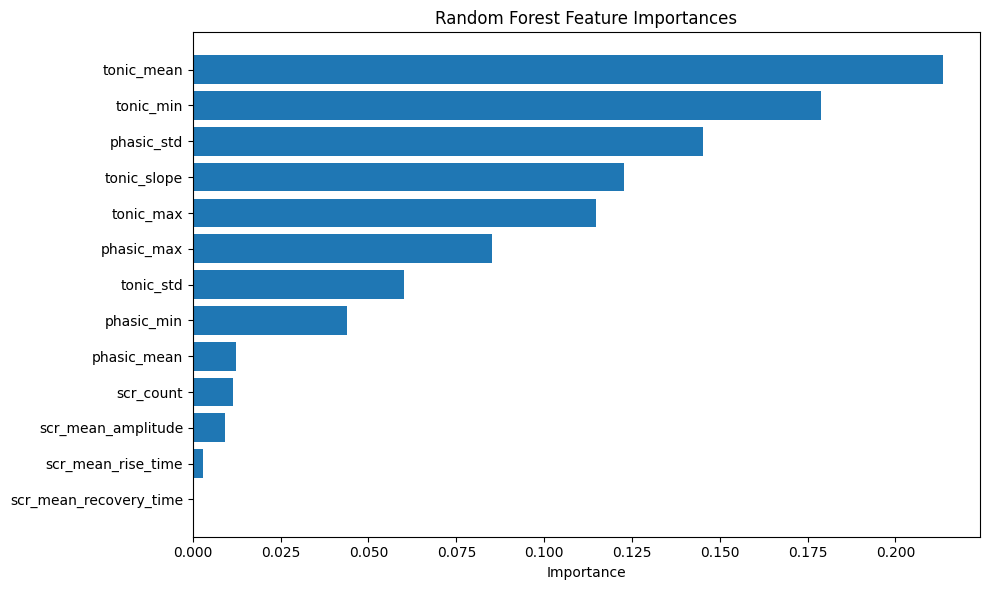

In [11]:
# Goal: look at the features that the model finds the most useful

importances = clf.feature_importances_
# higher num = more useful classification

# sorts the feature importances in descending order
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Feature importances:")
print(importance_df.to_string(index=False))

# plot
# horizontal bars
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
# leave one subject out (LOSO) with one subject as a placeholder

from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
# stratified = same class ratio in train and testing
# 5 splits = 5 different random train / test cuts
# test size means 20% of data is tested at a time

fold_accuracies = []

# sss.split -> generates pairs of index arrays
# train_idx -> row indices for training
# test_idx -> row indices for testing
for fold, (train_idx, test_idx) in enumerate(sss.split(X, y)):
    
    # uses index arrays to split features / labels into separate training and testing sets
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # fit scaler on ONLY training data
    scaler_fold = StandardScaler()
    X_train_scaled = scaler_fold.fit_transform(X_train) # mean / std from training only
    X_test_scaled = scaler_fold.transform(X_test) # applies the same training statistics

    # trains a new classifier
    clf_fold = RandomForestClassifier(n_estimators=100, random_state=42)
    clf_fold.fit(X_train_scaled, y_train)

    # does a prediction on test data, computes accuracy, stores, prints it
    y_pred = clf_fold.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(acc)
    print(f"Fold {fold+1} accuracy: {acc:.3f}")

# prints
print(f"\nMean accuracy: {np.mean(fold_accuracies):.3f}")
print(f"Std: {np.std(fold_accuracies):.3f}")
print(f"\nDetailed report (last fold):")
print(classification_report(y_test, y_pred, 
      target_names=['Baseline', 'Stress']))

Fold 1 accuracy: 1.000
Fold 2 accuracy: 0.818
Fold 3 accuracy: 1.000
Fold 4 accuracy: 0.909
Fold 5 accuracy: 1.000

Mean accuracy: 0.945
Std: 0.073

Detailed report (last fold):
              precision    recall  f1-score   support

    Baseline       1.00      1.00      1.00         7
      Stress       1.00      1.00      1.00         4

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



In [13]:
def process_subject(subject_id):
    # process one WESAD subject -- will return DataFrame, labels, and subject ID array

    path = f'WESAD/S{subject_id}/S{subject_id}.pkl'
    with open(path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    wrist = data['signal']['wrist']
    labels = data['label'].flatten()

    #process EDA
    eda_raw = wrist['EDA'].flatten()
    eda_signals, _ = nk.eda_process(eda_raw, sampling_rate=EDA_RATE)

    # downsample and align labels
    labels_eda = labels[::label_downsample_factor]
    labels_eda = labels_eda[:len(eda_signals)]
    eda_signals['Label'] = labels_eda

    # filter to baseline and stress only + remap to 0 and 1 (like cell 5)
    eda_signals = eda_signals[
        eda_signals['Label'].isin([1, 2])
    ].copy()
    eda_signals['Label'] = (eda_signals['Label'] == 2).astype(int)
    eda_signals = eda_signals.reset_index(drop=True)

    # extract windows
    feature_rows = []
    label_rows = []
    start = 0

    while start + SAMPLES_PER_WINDOW <= len(eda_signals):
        end = start + SAMPLES_PER_WINDOW
        window = eda_signals.iloc[start:end]
        window_labels = window['Label'].values

        if len(np.unique(window_labels)) > 1:
            start += SAMPLES_PER_STEP
            continue

        features = extract_features_from_window(window)
        feature_rows.append(features)
        label_rows.append(window_labels[0])
        start += SAMPLES_PER_STEP

    # builds dataframe -- np.full makes an array entirely out of the subject's id number so every window from subject 3 has a 3 in subject_arr
    # so that LOSO can know which windows belong to which subjects
    features_df = pd.DataFrame(feature_rows).fillna(0)
    labels_arr = np.array(label_rows)
    subject_arr = np.full(len(labels_arr), subject_id)

    return features_df, labels_arr, subject_arr


# test with all subjects. there are 17 total subjects, but subject 1 was excluded in the original study
all_features = []
all_labels = []
all_subjects = []

for sid in range (2, 18):
    # try and except is because subject 12 isn't in the original dataset
    try:
        print(f"Processing subject {sid}...")
    
        f, l, s = process_subject(sid)
        all_features.append(f)
        all_labels.append(l)
        all_subjects.append(s)
        print(f" Windows extracted: {len(f)}")
    except FileNotFoundError:
        print(f" Subject {sid} not found, skipping.")
    except Exception as e:
        print(f" Subject {sid} error: {e}, skipping")

X_all = np.vstack([f.values for f in all_features])
y_all = np.concatenate(all_labels)
groups_all = np.concatenate(all_subjects)

print(f"\nTotal windows across all subjects: {len(X_all)}")
print(f"Total baseline: {np.sum(y_all == 0)}")
print(f"Total stress: {np.sum(y_all == 1)}")

Processing subject 2...
 Windows extracted: 55
Processing subject 3...
 Windows extracted: 57
Processing subject 4...
 Windows extracted: 56
Processing subject 5...
 Windows extracted: 58
Processing subject 6...
 Windows extracted: 58
Processing subject 7...
 Windows extracted: 57
Processing subject 8...
 Windows extracted: 58
Processing subject 9...
 Windows extracted: 57
Processing subject 10...
 Windows extracted: 60
Processing subject 11...
 Windows extracted: 59
Processing subject 12...
 Subject 12 not found, skipping.
Processing subject 13...
 Windows extracted: 58
Processing subject 14...
 Windows extracted: 58
Processing subject 15...
 Windows extracted: 59
Processing subject 16...
 Windows extracted: 58
Processing subject 17...
 Windows extracted: 60

Total windows across all subjects: 868
Total baseline: 566
Total stress: 302


In [14]:
# real LOSO with all subjects

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import balanced_accuracy_score, classification_report

logo = LeaveOneGroupOut()
loso_accuracies = []
subject_ids_tested = []

for train_idx, test_idx in logo.split(X_all, y_all, groups=groups_all):

    # splits into training + testing data based on index arrays
    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]


    # get the subject tested on this fold
    test_subject = groups_all[test_idx[0]]

    # scales inside the fold like in cell 12
    scaler_loso = StandardScaler()
    X_train_scaled = scaler_loso.fit_transform(X_train)
    X_test_scaled = scaler_loso.transform(X_test)

    # trains a new classifier on all subjects
    clf_loso = RandomForestClassifier(n_estimators=100, random_state=42)
    clf_loso.fit(X_train_scaled, y_train)
    y_pred = clf_loso.predict(X_test_scaled)
    
    # computes the raw and balanced accuracy, stores and prints summary
    acc = accuracy_score(y_test, y_pred)
    loso_accuracies.append(acc)
    subject_ids_tested.append(test_subject)

    bal_acc = balanced_accuracy_score(y_test, y_pred)
    print(f"Subject {test_subject} | "
          f"Accuracy: {acc:.3f} | "
          f"Balanced: {bal_acc:.3f} | "
          f"n={len(test_idx)}")

print(f"\nMean LOSO accuracy: {np.mean(loso_accuracies):.3f}")
print(f"Std: {np.std(loso_accuracies):.3f}")
print(f"Min: {np.min(loso_accuracies):.3f}")
print(f"Max: {np.max(loso_accuracies):.3f}")

Subject 2 | Accuracy: 0.818 | Balanced: 0.751 | n=55
Subject 3 | Accuracy: 0.772 | Balanced: 0.732 | n=57
Subject 4 | Accuracy: 1.000 | Balanced: 1.000 | n=56
Subject 5 | Accuracy: 0.707 | Balanced: 0.741 | n=58
Subject 6 | Accuracy: 0.862 | Balanced: 0.824 | n=58
Subject 7 | Accuracy: 0.965 | Balanced: 0.961 | n=57
Subject 8 | Accuracy: 0.983 | Balanced: 0.976 | n=58
Subject 9 | Accuracy: 0.772 | Balanced: 0.671 | n=57
Subject 10 | Accuracy: 0.817 | Balanced: 0.760 | n=60
Subject 11 | Accuracy: 0.814 | Balanced: 0.845 | n=59
Subject 13 | Accuracy: 0.759 | Balanced: 0.816 | n=58
Subject 14 | Accuracy: 0.655 | Balanced: 0.500 | n=58
Subject 15 | Accuracy: 1.000 | Balanced: 1.000 | n=59
Subject 16 | Accuracy: 0.983 | Balanced: 0.975 | n=58
Subject 17 | Accuracy: 0.633 | Balanced: 0.682 | n=60

Mean LOSO accuracy: 0.836
Std: 0.121
Min: 0.633
Max: 1.000


In [15]:
# check for imbalances cuz subjects 4 and 15 had 100 accuracy 
for sid in [4, 15]:
    mask = groups_all == sid
    baseline = np.sum(y_all[mask] == 0)
    stress = np.sum(y_all[mask] == 1)
    total = baseline + stress
    print(f"Subject {sid}: {baseline} baseline, "
          f"{stress} stress, "
          f"majority class = {max(baseline,stress)/total:.1%}")

Subject 4: 37 baseline, 19 stress, majority class = 66.1%
Subject 15: 38 baseline, 21 stress, majority class = 64.4%
